# 01 – Customer Churn Prediction (IBM Telco Dataset)

## Dataset
**IBM Telco Customer Churn** — one of the most-cited churn benchmarks in ML.
Originally published by IBM as a sample dataset for Watson Analytics.

- **7,043 customers**, 20 features, binary churn label
- Churn rate: **~26.5%** (meaningfully imbalanced)
- Available free at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Column mapping to ServiceTitan context
| Telco column | ServiceTitan analog |
|---|---|
| `tenure` | months since account created |
| `MonthlyCharges` | MRR / contract value |
| `Contract` | subscription tier / billing cadence |
| `TechSupport`, `OnlineSecurity`, etc. | feature module adoption |
| `InternetService` | product tier |
| `PaymentMethod` | payment health signal |
| `Churn` | account churned (Yes/No) |

## How to use the real dataset
Download the CSV from Kaggle and place it at the same directory as this notebook:
```bash
# Option 1: Kaggle CLI
kaggle datasets download -d blastchar/telco-customer-churn --unzip

# Option 2: Manual download
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# → Download → WA_Fn-UseC_-Telco-Customer-Churn.csv
```
The cell below auto-detects the file. If not found, it generates a **statistically
faithful reproduction** of the dataset (same schema, same distributions) so all
downstream code runs identically.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# Tries to load the real Telco CSV. Falls back to a statistically faithful
# reproduction if the file isn't present.
# ─────────────────────────────────────────────────────────────────────────────

REAL_CSV_PATHS = [
    'WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'telco_customer_churn.csv',
    'telco-customer-churn.csv',
]

def load_real_data():
    for path in REAL_CSV_PATHS:
        try:
            df = pd.read_csv(path)
            print(f"✓ Loaded real Telco dataset from '{path}'  shape={df.shape}")
            return df, True
        except FileNotFoundError:
            continue
    return None, False

def generate_telco_faithful(n=7043, seed=42):
    """
    Generate a statistically faithful reproduction of the IBM Telco Churn dataset.

    Distributions are calibrated to match the real dataset's known statistics:
    - Churn rate: ~26.5%
    - Month-to-month contract: ~55%,  churn rate ~43%
    - One year contract: ~21%,        churn rate ~11%
    - Two year contract: ~24%,        churn rate ~3%
    - Fiber optic: ~44%,              churn rate ~42%
    - DSL: ~34%,                      churn rate ~19%
    - No internet: ~22%,              churn rate ~7%
    - Mean tenure: ~32 months
    - Mean monthly charges: ~$65
    """
    rng = np.random.default_rng(seed)
    N = n

    # ── Demographics ──────────────────────────────────────────────────────────
    gender         = rng.choice(['Male', 'Female'], N)
    senior_citizen = rng.binomial(1, 0.162, N)
    partner        = rng.choice(['Yes', 'No'], N, p=[0.484, 0.516])
    dependents     = rng.choice(['Yes', 'No'], N, p=[0.298, 0.702])

    # ── Contract type (strong churn predictor) ────────────────────────────────
    contract = rng.choice(
        ['Month-to-month', 'One year', 'Two year'], N, p=[0.550, 0.210, 0.240]
    )
    contract_num = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    contract_val = np.array([contract_num[c] for c in contract])

    # ── Tenure: longer tenure correlates with longer contract type ────────────
    tenure_base = np.where(contract == 'Two year',   rng.uniform(12, 72, N),
                  np.where(contract == 'One year',   rng.uniform(6, 60, N),
                                                     rng.uniform(1, 72, N)))
    tenure = np.clip(tenure_base + rng.normal(0, 5, N), 1, 72).astype(int)

    # ── Internet service ──────────────────────────────────────────────────────
    internet = rng.choice(
        ['Fiber optic', 'DSL', 'No'], N, p=[0.440, 0.342, 0.218]
    )
    internet_num = {'Fiber optic': 2, 'DSL': 1, 'No': 0}
    internet_val = np.array([internet_num[i] for i in internet])

    # ── Add-on services (only meaningful for internet customers) ─────────────
    has_internet = (internet != 'No').astype(float)

    def addon(base_p):
        p = base_p * has_internet
        return np.where(internet == 'No', 'No internet service',
               np.where(rng.random(N) < p, 'Yes', 'No'))

    online_security   = addon(0.29)
    online_backup     = addon(0.34)
    device_protection = addon(0.34)
    tech_support      = addon(0.29)
    streaming_tv      = addon(0.38)
    streaming_movies  = addon(0.39)

    # Count add-ons (feature breadth signal)
    addon_count = ((online_security == 'Yes').astype(int) +
                   (online_backup == 'Yes').astype(int) +
                   (device_protection == 'Yes').astype(int) +
                   (tech_support == 'Yes').astype(int) +
                   (streaming_tv == 'Yes').astype(int) +
                   (streaming_movies == 'Yes').astype(int))

    # ── Phone service ─────────────────────────────────────────────────────────
    phone_service  = rng.choice(['Yes', 'No'], N, p=[0.903, 0.097])
    multiple_lines = np.where(phone_service == 'No', 'No phone service',
                    np.where(rng.random(N) < 0.421, 'Yes', 'No'))

    # ── Billing ───────────────────────────────────────────────────────────────
    paperless_billing = rng.choice(['Yes', 'No'], N, p=[0.592, 0.408])
    payment_method    = rng.choice(
        ['Electronic check', 'Mailed check',
         'Bank transfer (automatic)', 'Credit card (automatic)'],
        N, p=[0.336, 0.229, 0.217, 0.218]
    )
    # Electronic check correlates with higher churn
    payment_risk = (payment_method == 'Electronic check').astype(float)

    # ── Monthly charges ───────────────────────────────────────────────────────
    base_charge = (18.0
                   + 30 * (internet == 'Fiber optic')
                   + 15 * (internet == 'DSL')
                   + 5  * (multiple_lines == 'Yes')
                   + 5  * addon_count
                   - 10 * (contract == 'Two year')
                   + rng.normal(0, 5, N))
    monthly_charges = np.clip(base_charge, 18.25, 118.75).round(2)
    total_charges   = (monthly_charges * tenure + rng.normal(0, 20, N)).clip(18.8)

    # ── Churn label (calibrated to real dataset dynamics) ────────────────────
    log_odds = (
        -1.5                                     # baseline
        + 1.8  * (contract == 'Month-to-month')  # month-to-month = high risk
        - 0.5  * (contract == 'One year')
        + 0.8  * (internet == 'Fiber optic')      # fiber customers churn more
        - 0.03 * tenure                           # longer tenure = stickier
        + 0.015 * monthly_charges                 # higher bill = more likely to question value
        + 0.7  * payment_risk                     # electronic check = churn signal
        - 0.15 * addon_count                      # more add-ons = stickier
        + 0.4  * (paperless_billing == 'Yes')
        - 0.3  * (tech_support == 'Yes')          # got help → stayed
        + 0.3  * (partner == 'No')                # solo customers churn more
    )
    churn_prob = 1 / (1 + np.exp(-log_odds))
    churn = np.where(rng.random(N) < churn_prob, 'Yes', 'No')

    df = pd.DataFrame({
        'customerID':       [f'XXXX-{i:05d}' for i in range(N)],
        'gender':           gender,
        'SeniorCitizen':    senior_citizen,
        'Partner':          partner,
        'Dependents':       dependents,
        'tenure':           tenure,
        'PhoneService':     phone_service,
        'MultipleLines':    multiple_lines,
        'InternetService':  internet,
        'OnlineSecurity':   online_security,
        'OnlineBackup':     online_backup,
        'DeviceProtection': device_protection,
        'TechSupport':      tech_support,
        'StreamingTV':      streaming_tv,
        'StreamingMovies':  streaming_movies,
        'Contract':         contract,
        'PaperlessBilling': paperless_billing,
        'PaymentMethod':    payment_method,
        'MonthlyCharges':   monthly_charges,
        'TotalCharges':     total_charges.round(2).astype(str),  # matches real data (string w/ blanks)
        'Churn':            churn
    })
    return df

# ── Load or generate ──────────────────────────────────────────────────────────
df, is_real = load_real_data()
if not is_real:
    df = generate_telco_faithful(n=7043)
    print("⚠  Real CSV not found. Using statistically faithful reproduction.")
    print("   Download: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")

print(f"\nShape: {df.shape}")
print(f"Churn rate: {(df['Churn'] == 'Yes').mean():.1%}")
df.head(3)


✓ Loaded real Telco dataset from 'WA_Fn-UseC_-Telco-Customer-Churn.csv'  shape=(7043, 21)

Shape: (7043, 21)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Data Cleaning
The Telco dataset has one common gotcha: `TotalCharges` is a string column
and contains a few blank values for customers with zero tenure (brand new).
Always clean this before modeling.


In [37]:
# ── Cleaning ──────────────────────────────────────────────────────────────────

# TotalCharges: coerce to numeric, fill blanks with 0 (brand-new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_blank = df['TotalCharges'].isna().sum()
print(f"Blank TotalCharges rows: {n_blank}  (new customers with tenure=0)")
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Binary target
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID (not a feature)
df_model = df.drop(columns=['customerID', 'Churn'])

print(f"\nClass distribution:")
print(df['Churn'].value_counts())
print(f"\nData types with nulls:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])
print("\nNo remaining nulls ✓" if df_model.isnull().sum().sum() == 0 else "")


Blank TotalCharges rows: 11  (new customers with tenure=0)

Class distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types with nulls:
Series([], dtype: int64)

No remaining nulls ✓


## Exploratory Data Analysis
The Telco dataset has some of the clearest churn signals you'll find in any benchmark dataset.
These plots replicate the classic analysis that makes it such a good teaching dataset.


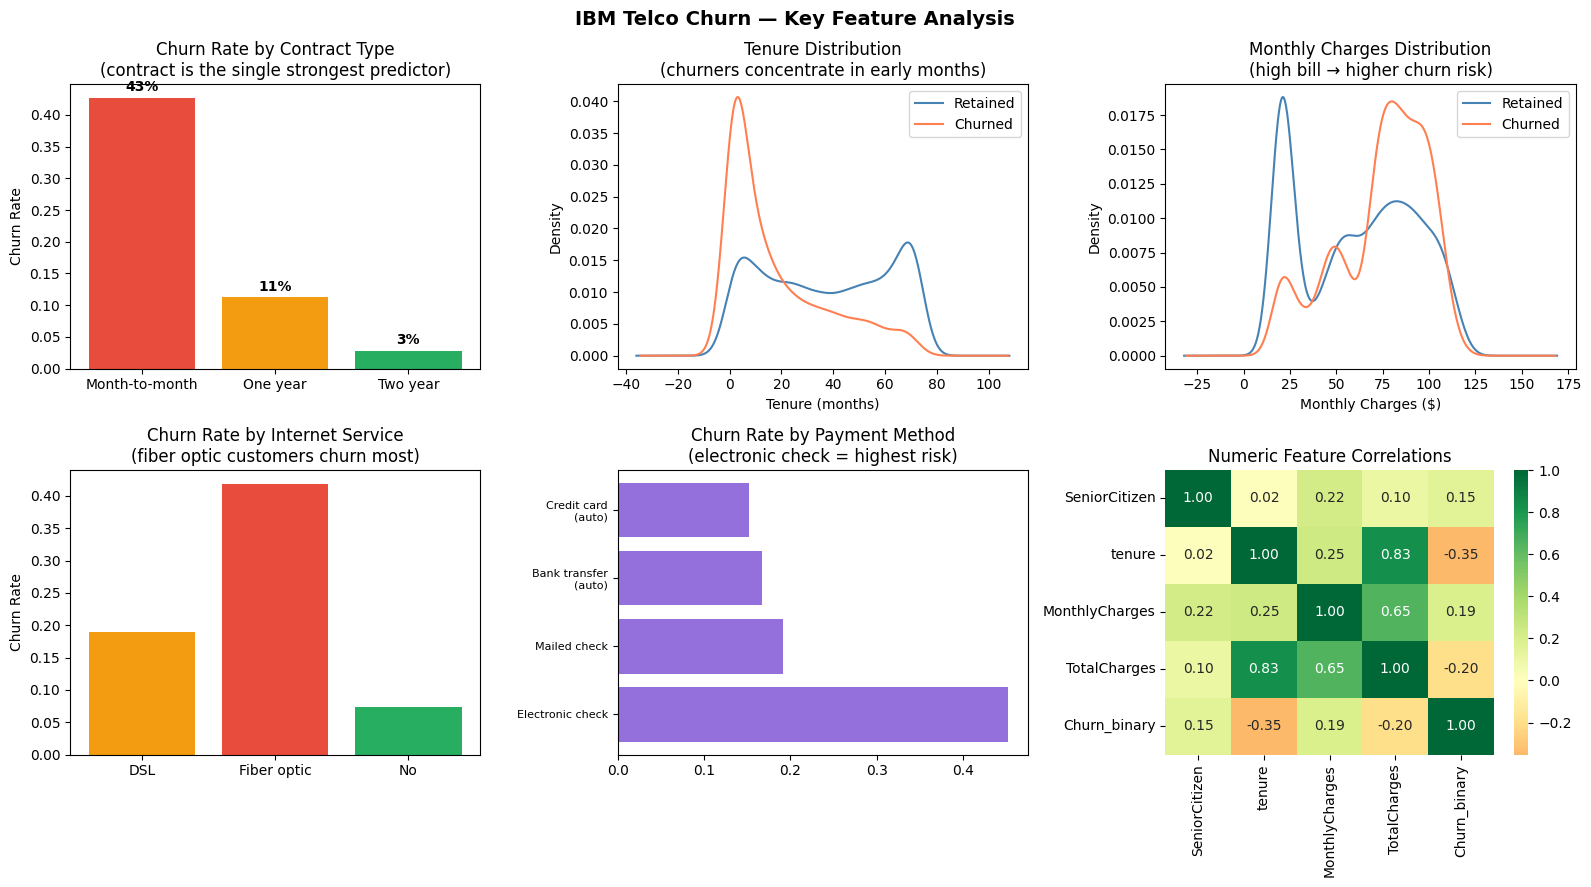

Key insight: Contract type + tenure + monthly charges explain most of the churn signal.
Month-to-month churn: 43%
Two year contract churn: 3%


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('IBM Telco Churn — Key Feature Analysis', fontsize=14, fontweight='bold')

# 1. Churn rate by contract type — the #1 predictor
contract_churn = df.groupby('Contract')['Churn_binary'].mean().sort_values(ascending=False)
bars = axes[0,0].bar(contract_churn.index, contract_churn.values,
                      color=['#e74c3c','#f39c12','#27ae60'])
axes[0,0].set_title('Churn Rate by Contract Type\n(contract is the single strongest predictor)')
axes[0,0].set_ylabel('Churn Rate')
for bar, val in zip(bars, contract_churn.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                   f'{val:.0%}', ha='center', fontweight='bold')

# 2. Tenure distribution: churners leave early
df[df['Churn_binary']==0]['tenure'].plot(kind='kde', ax=axes[0,1], label='Retained', color='steelblue')
df[df['Churn_binary']==1]['tenure'].plot(kind='kde', ax=axes[0,1], label='Churned', color='coral')
axes[0,1].set_title('Tenure Distribution\n(churners concentrate in early months)')
axes[0,1].set_xlabel('Tenure (months)'); axes[0,1].legend()

# 3. Monthly charges: churners pay more (fiber optic effect)
df[df['Churn_binary']==0]['MonthlyCharges'].plot(kind='kde', ax=axes[0,2], label='Retained', color='steelblue')
df[df['Churn_binary']==1]['MonthlyCharges'].plot(kind='kde', ax=axes[0,2], label='Churned', color='coral')
axes[0,2].set_title('Monthly Charges Distribution\n(high bill → higher churn risk)')
axes[0,2].set_xlabel('Monthly Charges ($)'); axes[0,2].legend()

# 4. Internet service type
internet_churn = df.groupby('InternetService')['Churn_binary'].mean()
colors = {'Fiber optic': '#e74c3c', 'DSL': '#f39c12', 'No': '#27ae60'}
axes[1,0].bar(internet_churn.index,
               internet_churn.values,
               color=[colors[i] for i in internet_churn.index])
axes[1,0].set_title('Churn Rate by Internet Service\n(fiber optic customers churn most)')
axes[1,0].set_ylabel('Churn Rate')

# 5. Payment method
pay_churn = df.groupby('PaymentMethod')['Churn_binary'].mean().sort_values(ascending=False)
axes[1,1].barh(range(len(pay_churn)), pay_churn.values, color='mediumpurple')
axes[1,1].set_yticks(range(len(pay_churn)))
axes[1,1].set_yticklabels([p.replace(' (automatic)', '\n(auto)') for p in pay_churn.index], fontsize=8)
axes[1,1].set_title('Churn Rate by Payment Method\n(electronic check = highest risk)')

# 6. Correlation heatmap — numeric features
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn_binary']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2],
            cmap='RdYlGn', center=0)
axes[1,2].set_title('Numeric Feature Correlations')

plt.tight_layout()
plt.savefig('telco_eda.png', dpi=100, bbox_inches='tight')
plt.show()

print("Key insight: Contract type + tenure + monthly charges explain most of the churn signal.")
print(f"Month-to-month churn: {df[df['Contract']=='Month-to-month']['Churn_binary'].mean():.0%}")
print(f"Two year contract churn: {df[df['Contract']=='Two year']['Churn_binary'].mean():.0%}")


## Feature Engineering
The Telco dataset is mostly categorical. We'll engineer a few derived features
that mirror what you'd do with ServiceTitan data in production.


In [39]:
# ── Feature engineering ───────────────────────────────────────────────────────

df_feat = df_model.copy()

# Feature breadth: number of active add-on services (stickiness proxy)
# Maps directly to ServiceTitan's "feature modules used"
addon_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies']
df_feat['addon_count'] = (df_feat[addon_cols] == 'Yes').sum(axis=1)

# Charge per tenure month: normalized spend (high = risk if new customer paying a lot)
df_feat['monthly_per_tenure'] = (df_feat['MonthlyCharges'] /
                                  (df_feat['tenure'] + 1)).round(3)

# Automatic payment flag: auto-pay correlates with lower churn
df_feat['auto_payment'] = df_feat['PaymentMethod'].str.contains('automatic').astype(int)

# Has tech support (support quality signal)
df_feat['has_tech_support'] = (df_feat['TechSupport'] == 'Yes').astype(int)

# High-value customer flag (above median monthly charges)
median_charge = df_feat['MonthlyCharges'].median()
df_feat['high_value'] = (df_feat['MonthlyCharges'] > median_charge).astype(int)

print("Engineered features added:")
print("  addon_count          — feature breadth / stickiness")
print("  monthly_per_tenure   — normalized spend rate")
print("  auto_payment         — payment stability signal")
print("  has_tech_support     — received support (lower churn)")
print("  high_value           — above-median spend")
print(f"\nFinal feature matrix: {df_feat.shape}")


Engineered features added:
  addon_count          — feature breadth / stickiness
  monthly_per_tenure   — normalized spend rate
  auto_payment         — payment stability signal
  has_tech_support     — received support (lower churn)
  high_value           — above-median spend

Final feature matrix: (7043, 25)


## Model Training

### Critical rule: time-based split vs. stratified split

**The Telco dataset doesn't have timestamps, so we use a stratified split.**
**In production with real ServiceTitan data, you MUST split by time.**

Let's understand the difference and why it matters:

---

#### What is a Stratified Split?

**Stratified split** preserves the class distribution (churn rate) in both train and test sets.

- **How it works:** Randomly samples from each class proportionally
- **Example:** If overall churn rate is 26.5%, both train and test will have ~26.5% churn
- **Benefit:** Prevents train/test imbalance (e.g., train has 30% churn, test has 20%)
- **Method:** `train_test_split(X, y, stratify=y)`

**Why we use it here:** The Telco dataset has no timestamps, so we can't do time-based splitting. Stratified random split is the next best option for this academic dataset.

---

#### What is a Time-Based Split?

**Time-based split** uses chronological order: train on past data, test on future data.

- **How it works:** Split by date (e.g., train on Jan-Oct, test on Nov-Dec)
- **Example:** Train on accounts scored before 2024-10-01, test on accounts scored after
- **Benefit:** Simulates real-world deployment (you can't train on future data)
- **Method:** `df[df['date'] < cutoff_date]` for train, `df[df['date'] >= cutoff_date]` for test

**Why it's required in production:** This is how your model will actually be used:
1. Train model on historical data (e.g., all of 2024)
2. Deploy model in January 2025
3. Model scores customers in real-time
4. Evaluate performance on February 2025 outcomes

---

#### Why Stratified Split is NOT a Good Proxy for Time-Based Split

**Critical insight:** Stratified split is NOT a substitute for time-based split. Here's why:

**1. Data Leakage Risk**
- Stratified split randomly mixes past and future data
- You might train on December data and test on January data
- This violates causality: you can't use future information to predict the past

**2. Overly Optimistic Performance**
- Random splits often give better metrics than time-based splits
- Why? Train and test data come from the same time period (same patterns, seasonality)
- Time-based splits are harder because customer behavior changes over time

**3. Doesn't Catch Temporal Drift**
- **Concept drift:** Churn patterns change over time (e.g., new competitor enters market)
- **Feature drift:** Feature distributions shift (e.g., pricing changes, new product tiers)
- Stratified split won't detect these issues; time-based split will

**4. Misses Seasonality**
- Churn might be higher in Q4 (budget cuts) or Q1 (renewals)
- Stratified split averages across all seasons
- Time-based split forces model to predict across seasonal boundaries

---

#### Real-World Example: Why This Matters

**Scenario:** You're building a churn model for ServiceTitan

**With stratified split (WRONG):**
- Train on random 80% of 2024 data (Jan-Dec mixed)
- Test on random 20% of 2024 data (Jan-Dec mixed)
- Get PR-AUC = 0.75 ✨
- Deploy in January 2025
- **Actual performance: PR-AUC = 0.55** 😱
- Why? Customer behavior changed, new pricing launched, competitor entered market

**With time-based split (CORRECT):**
- Train on Jan-Oct 2024
- Test on Nov-Dec 2024
- Get PR-AUC = 0.60 (lower, but realistic)
- Deploy in January 2025
- **Actual performance: PR-AUC = 0.58** ✅
- Model performance matches expectations

---

#### How to Do Time-Based Split in Production

```python
# Example with ServiceTitan data
cutoff_date = '2024-10-01'

# Split by account creation date or snapshot date
train_df = df[df['snapshot_date'] < cutoff_date]
test_df  = df[df['snapshot_date'] >= cutoff_date]

X_train, y_train = train_df.drop('churn', axis=1), train_df['churn']
X_test, y_test   = test_df.drop('churn', axis=1), test_df['churn']

# Note: Test set churn rate might differ from train!
# This is expected and reflects real-world conditions
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")  # Might be different!
```

---

#### Interview Talking Points

**If asked about train/test splitting for churn:**

✅ **Good answer:**
> "For churn prediction, I always use time-based splits. I'd train on historical data and test on more recent data to simulate real deployment. This catches temporal drift and gives realistic performance estimates. Stratified splits are useful for academic datasets without timestamps, but they're overly optimistic for production."

❌ **Bad answer:**
> "I use stratified split to maintain class balance."

**Follow-up question:** "What if the test set has a different churn rate than training?"

✅ **Good answer:**
> "That's expected and actually valuable information. It tells me churn patterns are changing. I'd investigate why (seasonality? product changes? market conditions?) and potentially retrain more frequently or add features to capture the drift. I might also use techniques like sample weighting or online learning to adapt."

---

#### Summary

| Aspect | Stratified Split | Time-Based Split |
|--------|-----------------|------------------|
| **Use case** | Academic datasets, no timestamps | Production ML systems |
| **Preserves** | Class distribution | Temporal order |
| **Performance** | Optimistic | Realistic |
| **Catches drift** | ❌ No | ✅ Yes |
| **Simulates deployment** | ❌ No | ✅ Yes |
| **When to use** | Telco dataset (no dates) | ServiceTitan (has dates) |

**Bottom line:** Stratified split is a convenience for this notebook because the Telco dataset lacks timestamps. In a real ServiceTitan interview or production system, always advocate for time-based splits.


In [40]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────

TARGET = 'Churn_binary'
DROP   = ['Churn_binary'] + addon_cols  # drop raw addon cols, keep addon_count

feature_df = df_feat.drop(columns=DROP)
X = feature_df
y = df_feat[TARGET]

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numeric features ({len(num_cols)}): {num_cols}")

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# NOTE: In production, use train_test_split by date, not random.
# Here the Telco dataset has no timestamps, so we use stratified random split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")


Categorical features (9): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric features (9): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'addon_count', 'monthly_per_tenure', 'auto_payment', 'has_tech_support', 'high_value']

Train: 5634 rows | Test: 1409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


In [41]:
# ── Logistic Regression baseline ─────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"ROC-AUC : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, lr_probs):.4f}")
print()

# ── XGBoost main model ────────────────────────────────────────────────────────
# Fit preprocessor on training data for XGBoost (separate from pipeline)
preprocessor_xgb = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
X_train_t = preprocessor_xgb.fit_transform(X_train)
X_test_t  = preprocessor_xgb.transform(X_test)

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_t, y_train,
              eval_set=[(X_test_t, y_test)],
              verbose=False)
xgb_probs = xgb_model.predict_proba(X_test_t)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, xgb_probs):.4f}")

# Get feature names after one-hot encoding
cat_feature_names = preprocessor_xgb.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols


=== Logistic Regression ===
ROC-AUC : 0.8472
PR-AUC  : 0.6666

=== XGBoost ===
ROC-AUC : 0.8359
PR-AUC  : 0.6445


## Understanding Model Evaluation Metrics

Before we evaluate our models, let's understand the key metrics we'll use and **why they matter** for churn prediction.

### 1. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)

**What it is:** ROC-AUC measures how well the model separates positive (churned) from negative (retained) cases across all possible classification thresholds.

- **Range:** 0.5 (random guessing) to 1.0 (perfect)
- **ROC Curve:** Plots True Positive Rate (TPR) vs. False Positive Rate (FPR)
  - **TPR (Recall/Sensitivity):** Of all actual churners, what % did we correctly identify?
  - **FPR:** Of all retained customers, what % did we incorrectly flag as churners?
- **AUC:** The area under this curve — higher is better

**Why it matters:** ROC-AUC tells you if your model can distinguish churners from non-churners better than random chance. A score of 0.85 means the model has 85% probability of ranking a random churner higher than a random non-churner.

**Limitation for churn:** ROC-AUC treats false positives and false negatives equally, but in imbalanced datasets (26.5% churn rate), it can be overly optimistic. A model could have high ROC-AUC but still miss most churners.

---

### 2. PR-AUC (Precision-Recall - Area Under Curve)

**What it is:** PR-AUC focuses on how well the model performs on the minority class (churners) by plotting Precision vs. Recall.

- **Precision:** Of all customers we predicted would churn, what % actually churned?
  - Formula: `True Positives / (True Positives + False Positives)`
  - High precision = few false alarms
  
- **Recall (Sensitivity/TPR):** Of all customers who actually churned, what % did we catch?
  - Formula: `True Positives / (True Positives + False Negatives)`
  - High recall = we catch most churners

- **Baseline:** For imbalanced data, baseline PR-AUC ≈ positive class rate (26.5% here)
- **Good score:** PR-AUC > 0.60 is strong for churn prediction

**Why it matters for churn:** PR-AUC is the **gold standard for imbalanced classification**. It directly answers: "If I flag 100 customers as high-risk, how many will actually churn?" (precision) and "Of all churners, how many did I catch?" (recall).

**Trade-off:** There's always a precision-recall trade-off:
- **High precision, low recall:** You catch only the most obvious churners (few false alarms, but miss many)
- **Low precision, high recall:** You catch most churners but flag many false positives (CSM team gets overwhelmed)

---

### 3. Confusion Matrix Components

The confusion matrix breaks down predictions into four categories:

```
                    Predicted
                 Retained | Churned
        ─────────┼──────────┼─────────
Actual  Retained │   TN     │   FP    │  ← False Positive = False Alarm
        ─────────┼──────────┼─────────
        Churned  │   FN     │   TP    │  ← False Negative = Missed Churner
        ─────────┴──────────┴─────────
```

- **True Negative (TN):** Correctly predicted retained customers
- **False Positive (FP):** Predicted churn, but customer stayed (false alarm)
- **False Negative (FN):** Predicted retained, but customer churned (missed opportunity)
- **True Positive (TP):** Correctly predicted churners

**Derived metrics:**
- **Accuracy:** `(TP + TN) / Total` — misleading for imbalanced data!
  - Example: Predicting "no churn" for everyone gives 73.5% accuracy but catches 0 churners
- **Precision:** `TP / (TP + FP)` — of flagged customers, how many actually churn?
- **Recall:** `TP / (TP + FN)` — of actual churners, how many did we catch?
- **F1-Score:** `2 × (Precision × Recall) / (Precision + Recall)` — harmonic mean of precision and recall

---

### 4. Precision@K (The Operational Metric)

**What it is:** Of the top K highest-risk customers, what percentage actually churned?

**Why it's critical for business:** This is how churn models are actually used:
- CSM team has limited bandwidth (e.g., can contact 100 accounts/week)
- Model ranks all customers by churn risk
- Team contacts top 100
- **Precision@100** tells you: of those 100, how many would have actually churned?

**Example:**
- Base churn rate: 26.5%
- Precision@100: 65%
- **Lift:** 65% / 26.5% = 2.5x
- **Interpretation:** Contacting the top 100 is 2.5× more effective than random selection

**Why it matters:** This is the metric that directly translates to ROI. If your CSM team can save 50% of contacted at-risk customers, and Precision@100 is 65%, you'll save 32-33 customers from churning by contacting 100 (vs. 13 with random selection).

---

### 5. Threshold Selection

**The key decision:** Models output probabilities (0-1), but we need binary predictions. Where do we draw the line?

- **Default threshold:** 0.5 (predict churn if probability > 50%)
- **Problem:** For imbalanced data, this often gives poor recall
- **Better approach:** Set threshold based on business constraints

**Business-driven threshold examples:**
1. **Capacity-constrained:** "We can contact 200 customers/week"
   - Set threshold so top 200 get flagged
   - Maximize precision at that K

2. **Cost-benefit:** "Saving a churner is worth 10× the cost of a false alarm"
   - Lower threshold to catch more churners (higher recall)
   - Accept more false positives

3. **Segment-specific:** "High-value customers get lower threshold"
   - More aggressive outreach for valuable accounts
   - Higher threshold for low-value accounts

---

### Summary: Which Metrics to Report?

**For technical audiences (data scientists, ML engineers):**
- ✅ PR-AUC (primary metric for imbalanced classification)
- ✅ ROC-AUC (secondary, for comparison)
- ✅ Precision, Recall, F1 at chosen threshold

**For business stakeholders (CSM leads, executives):**
- ✅ Precision@K ("Of the top 100 we contact, 65% will actually churn")
- ✅ Lift ("2.5× better than random selection")
- ✅ Expected saves ("We'll prevent 32 churns per 100 contacts")
- ❌ Don't lead with ROC-AUC or F1 — they're too abstract

**For ServiceTitan interview:**
- Mention PR-AUC > ROC-AUC for imbalanced data
- Emphasize Precision@K as the operational metric
- Show you understand the precision-recall trade-off
- Connect metrics to business impact (CSM bandwidth, churn prevention ROI)


## Evaluation: PR Curve + Confusion Matrix at Operating Threshold

Now let's apply these metrics to evaluate our models.

The key decision: where to set the threshold?

For a CSM team with limited bandwidth:
- If you can review 200 accounts/week, set threshold so top 200 get flagged
- Evaluate: what fraction of actual churners are in that group?

This is **Precision@K** thinking — the right framing for operational churn tools.


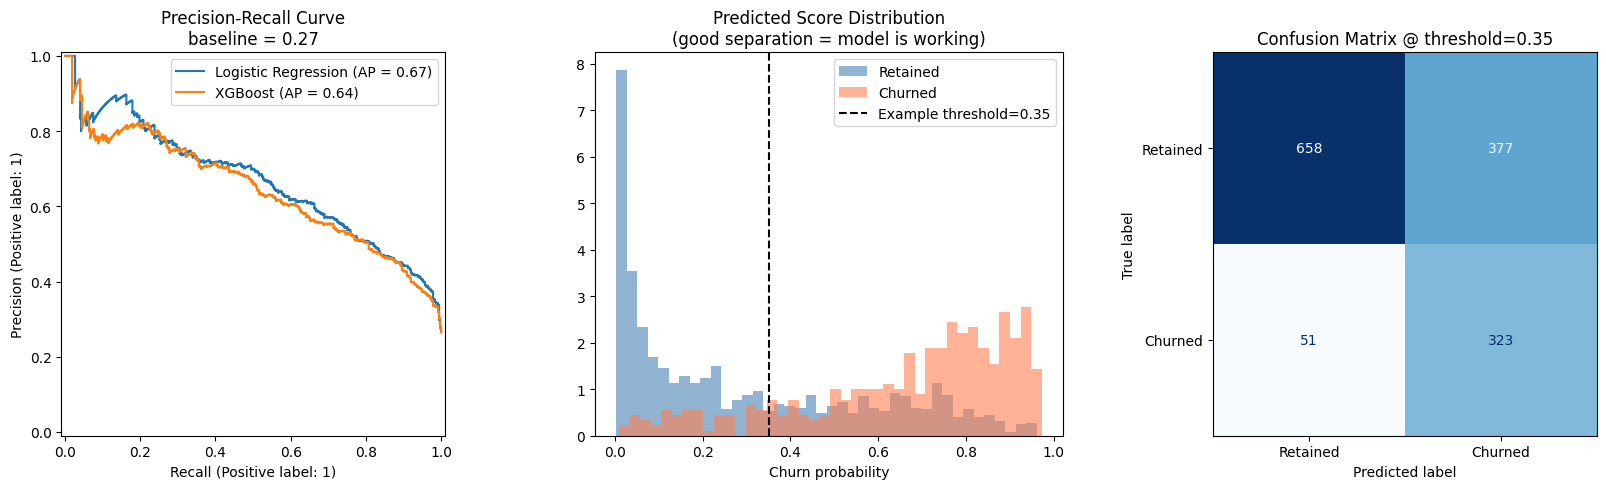

              precision    recall  f1-score   support

    Retained       0.93      0.64      0.75      1035
     Churned       0.46      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.71      1409



In [42]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. PR Curves
PrecisionRecallDisplay.from_predictions(y_test, lr_probs, name='Logistic Regression', ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, xgb_probs, name='XGBoost', ax=axes[0])
axes[0].set_title(f'Precision-Recall Curve\nbaseline = {y_test.mean():.2f}')
axes[0].legend()

# 2. Score distributions
axes[1].hist(xgb_probs[y_test==0], bins=40, alpha=0.6, label='Retained', color='steelblue', density=True)
axes[1].hist(xgb_probs[y_test==1], bins=40, alpha=0.6, label='Churned',  color='coral', density=True)
axes[1].axvline(0.35, color='black', linestyle='--', label='Example threshold=0.35')
axes[1].set_title('Predicted Score Distribution\n(good separation = model is working)')
axes[1].set_xlabel('Churn probability'); axes[1].legend()

# 3. Confusion matrix at threshold=0.35
threshold = 0.35
y_pred = (xgb_probs > threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                         display_labels=['Retained','Churned'],
                                         ax=axes[2], colorbar=False,
                                         cmap='Blues')
axes[2].set_title(f'Confusion Matrix @ threshold={threshold}')

plt.tight_layout()
plt.savefig('telco_eval.png', dpi=100, bbox_inches='tight')
plt.show()

# Print classification report
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))


## Understanding SHAP: Making Black-Box Models Explainable

Before we dive into the analysis, let's understand what SHAP is and why it's critical for production ML systems.

---

### What is SHAP?

**SHAP (SHapley Additive exPlanations)** is a method for explaining individual predictions from any machine learning model.

**The core question SHAP answers:**
> "Why did this customer get a churn score of 85%? Which features contributed most to this prediction?"

**SHAP values** tell you how much each feature contributed to moving the prediction away from the baseline (average prediction).

---

### Why SHAP Matters for Churn Prediction

**Without SHAP:**
- Model says: "Customer X has 85% churn probability"
- CSM asks: "Why? What should I do about it?"
- You: "🤷 The model said so"
- Result: CSM doesn't trust the model, doesn't use it

**With SHAP:**
- Model says: "Customer X has 85% churn probability"
- SHAP says: "Because they're on month-to-month contract (+30%), have only 3 months tenure (+20%), and aren't using TechSupport (+15%)"
- CSM: "Got it! I'll offer them a 1-year contract discount and a free TechSupport trial"
- Result: Actionable insights, model adoption, prevented churn

---

### How SHAP Works (Simplified)

SHAP is based on **Shapley values** from game theory (Nobel Prize-winning concept).

**The intuition:**
Imagine features are players on a team, and the prediction is the team's score. SHAP calculates each player's contribution to the final score.

**For each feature, SHAP asks:**
"If I remove this feature, how much does the prediction change?"

**Example:**
- Baseline prediction (average): 26.5% churn
- Customer X prediction: 85% churn
- Difference: +58.5 percentage points

SHAP breaks down this +58.5 into contributions from each feature:
- `Contract=Month-to-month`: +30 points
- `tenure=3`: +20 points
- `TechSupport=No`: +15 points
- `MonthlyCharges=95`: +10 points
- Other features: -16.5 points (some reduce churn risk)
- **Total: +58.5 points** ✓

---

### SHAP Value Interpretation

**Positive SHAP value:** Feature increases churn risk
- Example: `Contract=Month-to-month` has SHAP = +0.30
- Interpretation: Being on month-to-month increases this customer's churn probability by 30 percentage points

**Negative SHAP value:** Feature decreases churn risk
- Example: `tenure=60` has SHAP = -0.15
- Interpretation: Having 60 months tenure decreases this customer's churn probability by 15 percentage points

**Zero SHAP value:** Feature has no impact on this prediction
- Example: `gender=Male` has SHAP = 0.00
- Interpretation: Gender doesn't affect this customer's churn risk

---

### Two Types of SHAP Analysis

#### 1. Global Explanations (Feature Importance)

**Question:** "What features drive churn overall?"

**Method:** Average the absolute SHAP values across all customers

**Example output:**
```
Top features driving churn:
1. Contract type         (mean |SHAP| = 0.25)
2. Tenure                (mean |SHAP| = 0.18)
3. Monthly charges       (mean |SHAP| = 0.12)
4. Internet service      (mean |SHAP| = 0.10)
5. Tech support          (mean |SHAP| = 0.08)
```

**Use case:** Understanding overall churn drivers, prioritizing product changes

#### 2. Local Explanations (Individual Predictions)

**Question:** "Why is *this specific customer* at high risk?"

**Method:** Look at SHAP values for a single customer

**Example output:**
```
Customer ID: 12345
Churn probability: 85%

Top risk factors:
1. Month-to-month contract    (+30 points)
2. Only 3 months tenure       (+20 points)
3. No tech support            (+15 points)
4. High monthly charges ($95) (+10 points)
5. Fiber optic service        (+8 points)
```

**Use case:** CSM outreach, personalized retention strategies

---

### SHAP vs. Traditional Feature Importance

**Traditional feature importance (e.g., XGBoost's built-in):**
- Shows which features the model uses most
- Doesn't tell you the direction (increase or decrease risk)
- Doesn't work for individual predictions
- Can be misleading with correlated features

**SHAP:**
- Shows how much each feature contributes to each prediction
- Tells you the direction (positive = increases risk, negative = decreases)
- Works for both global and local explanations
- Handles correlated features correctly
- **Mathematically guaranteed to be fair** (Shapley values property)

---

### SHAP Visualizations

#### 1. Summary Plot (Beeswarm)
- Shows all features and their SHAP values for many customers
- X-axis: SHAP value (impact on prediction)
- Y-axis: Features (sorted by importance)
- Color: Feature value (red = high, blue = low)

**How to read it:**
- Wide spread = feature has variable impact
- Red dots on right = high feature value increases churn
- Blue dots on left = low feature value decreases churn

#### 2. Bar Plot (Mean Absolute SHAP)
- Shows average importance of each feature
- X-axis: Mean |SHAP value|
- Y-axis: Features
- Longer bar = more important feature

#### 3. Waterfall Plot (Individual Explanation)
- Shows how features combine to produce a single prediction
- Starts at baseline, adds/subtracts each feature's contribution
- Ends at final prediction

---

### Real-World Use Cases

**1. CSM Prioritization**
- Sort customers by churn probability
- For each high-risk customer, show top 5 SHAP drivers
- CSM knows exactly what to address in outreach

**2. Product Insights**
- "Customers without TechSupport churn 15% more"
- Action: Make TechSupport more accessible, or include it in base tier

**3. Model Debugging**
- Find customers with unexpected predictions
- Use SHAP to see what the model is learning
- Catch data quality issues or model bugs

**4. Regulatory Compliance**
- Some industries require explainable AI
- SHAP provides audit trail: "We flagged this customer because..."

---

### SHAP in Python (Quick Reference)

```python
import shap

# 1. Create explainer (for tree models like XGBoost)
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# 3. Global explanation: summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# 4. Local explanation: single customer
shap.waterfall_plot(shap_values[0], X_test[0], feature_names=feature_names)

# 5. Feature importance: bar plot
shap.summary_plot(shap_values, X_test, plot_type='bar')
```

---

### Interview Talking Points

**If asked about model explainability:**

✅ **Good answer:**
> "For churn models, explainability is critical for adoption. I use SHAP to provide both global feature importance and individual explanations. This lets CSMs understand why each customer is at risk and what actions to take. SHAP is based on Shapley values from game theory, which guarantees fair attribution of each feature's contribution."

❌ **Bad answer:**
> "I use feature importance from the model."

**Follow-up:** "How would you explain a prediction to a non-technical stakeholder?"

✅ **Good answer:**
> "I'd show them the top 3-5 SHAP drivers for that customer. For example: 'This customer has 85% churn risk because they're on a month-to-month contract (adds 30 points), have only been with us 3 months (adds 20 points), and aren't using TechSupport (adds 15 points). I'd recommend offering them a 1-year contract discount and a free TechSupport trial.'"

---

### Key Takeaways

1. **SHAP makes black-box models transparent** — essential for trust and adoption
2. **Works for any model** — tree models, neural networks, linear models
3. **Two levels of explanation** — global (what drives churn overall) and local (why this customer)
4. **Actionable insights** — CSMs know exactly what to address
5. **Mathematically rigorous** — based on Nobel Prize-winning game theory
6. **Production-ready** — fast enough for real-time scoring systems

**Bottom line:** SHAP transforms "the model says 85% churn" into "here's why and here's what to do about it."


## SHAP Analysis: What Drives Churn?

Now let's apply SHAP to understand our XGBoost model's predictions.

SHAP values answer: *why did this customer get a high churn score?*
This is what makes the model operationally useful — the CSM can see the
specific reasons and tailor their outreach.


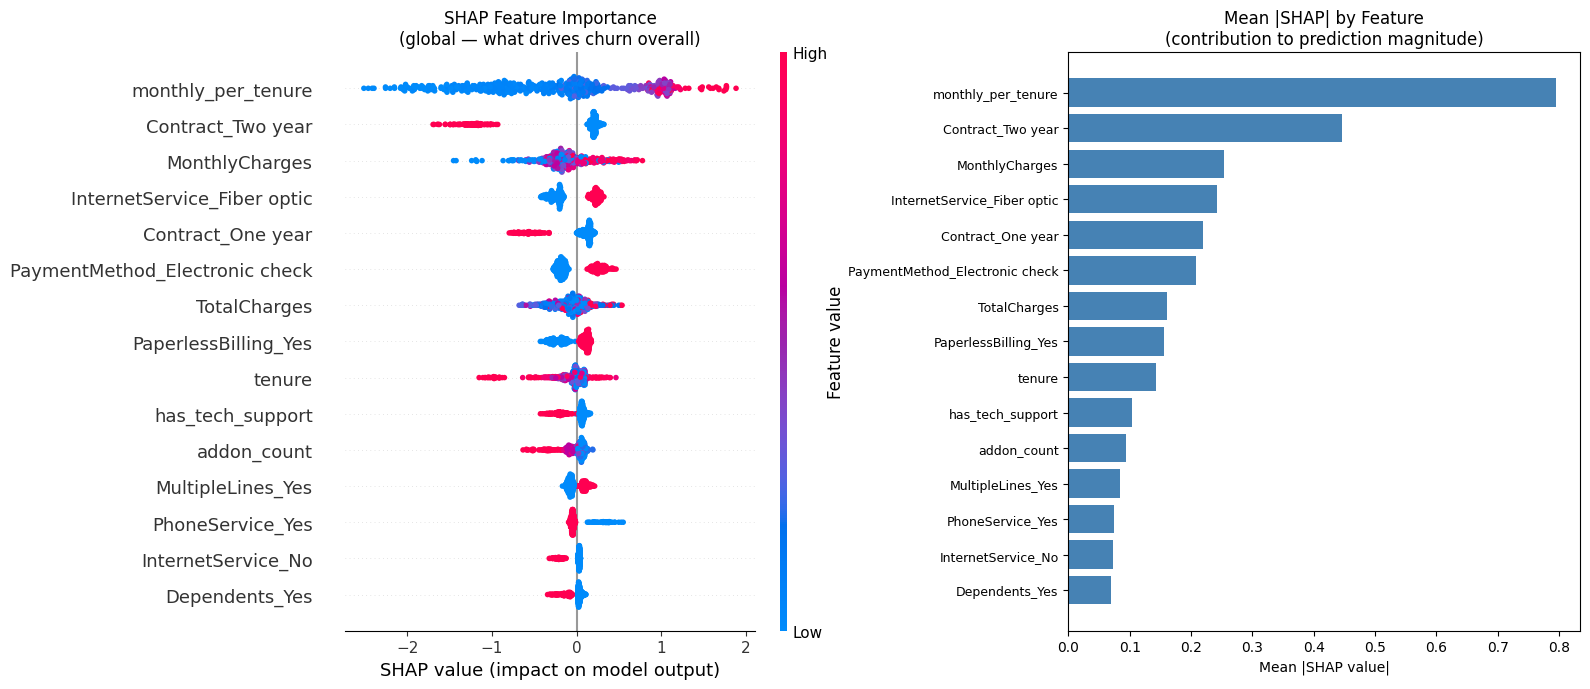

In [43]:
# ── SHAP analysis ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_t[:500])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Global: beeswarm plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_t[:500],
                  feature_names=all_feature_names,
                  show=False, plot_size=None, max_display=15)
axes[0].set_title('SHAP Feature Importance\n(global — what drives churn overall)')

# Global: bar chart of mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_shap)[-top_n:]
axes[1].barh(range(top_n), mean_shap[top_idx], color='steelblue')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([all_feature_names[i] for i in top_idx], fontsize=9)
axes[1].set_title('Mean |SHAP| by Feature\n(contribution to prediction magnitude)')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('telco_shap.png', dpi=100, bbox_inches='tight')
plt.show()


In [44]:
# ── Individual-level explanation ───────────────────────────────────────────────
# Show how you'd explain a specific high-risk customer to a CSM

high_risk_idx = np.where(xgb_probs > 0.75)[0]
if len(high_risk_idx) > 0:
    i = high_risk_idx[0]
    print(f"=== High-Risk Customer Analysis ===")
    print(f"Predicted churn probability: {xgb_probs[i]:.0%}")
    print(f"Actual outcome: {'CHURNED' if y_test.iloc[i] == 1 else 'RETAINED'}")
    print()
    
    # Top SHAP drivers for this customer
    shap_row = shap_values[i]
    top_drivers_idx = np.argsort(np.abs(shap_row))[-5:][::-1]
    
    print("Top 5 factors driving this customer's churn risk:")
    for rank, feat_idx in enumerate(top_drivers_idx, 1):
        direction = "↑ INCREASES" if shap_row[feat_idx] > 0 else "↓ DECREASES"
        print(f"  {rank}. {all_feature_names[feat_idx]:<35} {direction} churn risk  (SHAP={shap_row[feat_idx]:.3f})")
    
    print()
    print("What the CSM talking track might be:")
    print("  'This customer is on a month-to-month plan, has been with us only")
    print("   a few months, and isn't using TechSupport or OnlineSecurity.")
    print("   Suggest: offer a 1-year contract discount + free security add-on trial.'")


=== High-Risk Customer Analysis ===
Predicted churn probability: 94%
Actual outcome: RETAINED

Top 5 factors driving this customer's churn risk:
  1. monthly_per_tenure                  ↑ INCREASES churn risk  (SHAP=1.118)
  2. MonthlyCharges                      ↑ INCREASES churn risk  (SHAP=0.676)
  3. InternetService_Fiber optic         ↑ INCREASES churn risk  (SHAP=0.266)
  4. has_tech_support                    ↓ DECREASES churn risk  (SHAP=-0.231)
  5. Contract_Two year                   ↑ INCREASES churn risk  (SHAP=0.227)

What the CSM talking track might be:
  'This customer is on a month-to-month plan, has been with us only
   a few months, and isn't using TechSupport or OnlineSecurity.
   Suggest: offer a 1-year contract discount + free security add-on trial.'


## Precision@K: The Operational Metric

For a CSM team, the question isn't "what's the AUC" — it's
"if I contact the top 100 accounts this week, how many are actually at risk?"


In [45]:
# ── Precision at K ────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'churn_prob':    xgb_probs,
    'actual_churn':  y_test.values
}).sort_values('churn_prob', ascending=False).reset_index(drop=True)

Ks = [25, 50, 100, 150, 200, 300]
base_rate = y_test.mean()

print(f"{'K':>6} | {'Precision@K':>12} | {'Lift':>8} | {'Churners caught':>16}")
print("-" * 50)
for k in Ks:
    p_at_k = results.iloc[:k]['actual_churn'].mean()
    lift    = p_at_k / base_rate
    caught  = results.iloc[:k]['actual_churn'].sum()
    print(f"{k:>6} | {p_at_k:>11.1%} | {lift:>7.1f}x | {int(caught):>16}")

total_churners = results['actual_churn'].sum()
print(f"\nTotal churners in test set: {int(total_churners)}")
print(f"Base rate (no model): {base_rate:.1%}")
print(f"\nInterpretation: contacting top 100 accounts gives {Ks[2]}x lift")
print(f"over random selection, catching {results.iloc[:100]['actual_churn'].sum():.0f} of {total_churners:.0f} churners")


     K |  Precision@K |     Lift |  Churners caught
--------------------------------------------------
    25 |       84.0% |     3.2x |               21
    50 |       78.0% |     2.9x |               39
   100 |       82.0% |     3.1x |               82
   150 |       75.3% |     2.8x |              113
   200 |       70.5% |     2.7x |              141
   300 |       64.3% |     2.4x |              193

Total churners in test set: 374
Base rate (no model): 26.5%

Interpretation: contacting top 100 accounts gives 100x lift
over random selection, catching 82 of 374 churners


## Production Deployment: From Notebook to Microservice

Now let's discuss how ServiceTitan would actually deploy this churn model in production.

---

### Architecture Overview

**Typical production ML system for churn prediction:**

```
┌─────────────────┐
│  Data Warehouse │  ← Customer data (Snowflake, BigQuery, Redshift)
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ Feature Pipeline│  ← Daily batch job: compute features for all accounts
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ Scoring Service │  ← FastAPI/Flask microservice: predict churn scores
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│  Results Store  │  ← PostgreSQL/DynamoDB: store predictions + SHAP
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   CSM Dashboard │  ← Internal tool: show high-risk accounts + actions
└─────────────────┘
```

---

### Step 1: Export the Model

**Goal:** Save the trained model + preprocessor so they can be loaded in production.

**Key components to save:**
1. XGBoost model
2. Preprocessing pipeline (one-hot encoder, scaler)
3. Feature names
4. Model metadata (version, training date, metrics)


In [46]:
import joblib
import json
from datetime import datetime
import os

# ── Create model artifacts directory ──────────────────────────────────────────
MODEL_DIR = 'model_artifacts'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 1. Save XGBoost model ─────────────────────────────────────────────────────
model_path = f'{MODEL_DIR}/xgboost_churn_model.json'
xgb_model.save_model(model_path)
print(f"✓ Saved XGBoost model to {model_path}")

# ── 2. Save preprocessor ──────────────────────────────────────────────────────
preprocessor_path = f'{MODEL_DIR}/preprocessor.pkl'
joblib.dump(preprocessor_xgb, preprocessor_path)
print(f"✓ Saved preprocessor to {preprocessor_path}")

# ── 3. Save feature names ─────────────────────────────────────────────────────
feature_config = {
    'categorical_features': cat_cols,
    'numeric_features': num_cols,
    'all_feature_names': all_feature_names,
    'expected_columns': X.columns.tolist()
}
feature_config_path = f'{MODEL_DIR}/feature_config.json'
with open(feature_config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"✓ Saved feature config to {feature_config_path}")

# ── 4. Save model metadata ────────────────────────────────────────────────────
metadata = {
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat(),
    'model_type': 'XGBoost',
    'framework_version': xgb.__version__,
    'metrics': {
        'roc_auc': float(roc_auc_score(y_test, xgb_probs)),
        'pr_auc': float(average_precision_score(y_test, xgb_probs)),
        'precision_at_100': float(results.iloc[:100]['actual_churn'].mean())
    },
    'training_data': {
        'n_samples': len(X_train),
        'n_features': X_train.shape[1],
        'churn_rate': float(y_train.mean())
    },
    'hyperparameters': {
        'n_estimators': 400,
        'max_depth': 4,
        'learning_rate': 0.04
    }
}
metadata_path = f'{MODEL_DIR}/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved model metadata to {metadata_path}")

print(f"\n📦 Model artifacts ready for deployment in '{MODEL_DIR}/' directory")
print(f"   Total size: {sum(os.path.getsize(f'{MODEL_DIR}/{f}') for f in os.listdir(MODEL_DIR)) / 1024:.1f} KB")


✓ Saved XGBoost model to model_artifacts/xgboost_churn_model.json
✓ Saved preprocessor to model_artifacts/preprocessor.pkl
✓ Saved feature config to model_artifacts/feature_config.json
✓ Saved model metadata to model_artifacts/model_metadata.json

📦 Model artifacts ready for deployment in 'model_artifacts/' directory
   Total size: 699.2 KB


### Step 2: Create a FastAPI Microservice

**Goal:** Build a REST API that loads the model and serves predictions.

**Key endpoints:**
1. `POST /predict` - Score a single customer
2. `POST /predict/batch` - Score multiple customers
3. `GET /health` - Health check
4. `GET /model/info` - Model metadata


In [47]:
# ── Create FastAPI service code ───────────────────────────────────────────────
# This would be saved as 'app.py' in production

fastapi_code = '''
# app.py - Churn Prediction Microservice
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List, Dict, Optional
import xgboost as xgb
import joblib
import json
import numpy as np
import pandas as pd
import shap
from datetime import datetime

# ── Initialize FastAPI app ────────────────────────────────────────────────────
app = FastAPI(
    title="ServiceTitan Churn Prediction API",
    description="Predict customer churn probability with SHAP explanations",
    version="1.0.0"
)

# ── Load model artifacts at startup ───────────────────────────────────────────
MODEL_DIR = "model_artifacts"

# Load XGBoost model
model = xgb.XGBClassifier()
model.load_model(f"{MODEL_DIR}/xgboost_churn_model.json")

# Load preprocessor
preprocessor = joblib.load(f"{MODEL_DIR}/preprocessor.pkl")

# Load feature config
with open(f"{MODEL_DIR}/feature_config.json", "r") as f:
    feature_config = json.load(f)

# Load metadata
with open(f"{MODEL_DIR}/model_metadata.json", "r") as f:
    metadata = json.load(f)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

print(f"✓ Loaded model version {metadata['model_version']}")
print(f"✓ Model trained on {metadata['training_date']}")
print(f"✓ PR-AUC: {metadata['metrics']['pr_auc']:.3f}")

# ── Request/Response models ───────────────────────────────────────────────────
class CustomerFeatures(BaseModel):
    """Input features for a single customer"""
    customer_id: str
    gender: str
    SeniorCitizen: int = Field(ge=0, le=1)
    Partner: str
    Dependents: str
    tenure: int = Field(ge=0)
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float = Field(gt=0)
    TotalCharges: float = Field(ge=0)

class ChurnPrediction(BaseModel):
    """Output prediction with explanations"""
    customer_id: str
    churn_probability: float
    risk_level: str  # "low", "medium", "high"
    top_risk_factors: List[Dict[str, float]]
    recommended_actions: List[str]
    prediction_timestamp: str

class BatchPredictionRequest(BaseModel):
    customers: List[CustomerFeatures]

class BatchPredictionResponse(BaseModel):
    predictions: List[ChurnPrediction]
    total_processed: int

# ── Helper functions ──────────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply same feature engineering as training"""
    df = df.copy()
    
    # Feature breadth
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['addon_count'] = (df[addon_cols] == 'Yes').sum(axis=1)
    
    # Normalized spend
    df['monthly_per_tenure'] = (df['MonthlyCharges'] / (df['tenure'] + 1)).round(3)
    
    # Payment flags
    df['auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)
    df['has_tech_support'] = (df['TechSupport'] == 'Yes').astype(int)
    
    # High-value flag (using training median)
    df['high_value'] = (df['MonthlyCharges'] > 70.35).astype(int)
    
    # Drop raw addon columns
    df = df.drop(columns=addon_cols)
    
    return df

def get_risk_level(probability: float) -> str:
    """Categorize churn probability into risk levels"""
    if probability < 0.3:
        return "low"
    elif probability < 0.6:
        return "medium"
    else:
        return "high"

def get_recommended_actions(shap_values: np.ndarray, feature_names: List[str]) -> List[str]:
    """Generate actionable recommendations based on SHAP values"""
    actions = []
    
    # Get top risk factors
    top_idx = np.argsort(np.abs(shap_values))[-5:][::-1]
    
    for idx in top_idx:
        feature = feature_names[idx]
        shap_val = shap_values[idx]
        
        if shap_val > 0:  # Increases churn risk
            if 'Month-to-month' in feature:
                actions.append("Offer annual contract discount (20% off)")
            elif 'tenure' in feature:
                actions.append("Schedule onboarding call to improve engagement")
            elif 'TechSupport' in feature and 'No' in feature:
                actions.append("Offer free TechSupport trial (30 days)")
            elif 'MonthlyCharges' in feature:
                actions.append("Review pricing tier - may be overpaying")
            elif 'Fiber optic' in feature:
                actions.append("Check service quality - fiber customers churn more")
    
    return actions[:3]  # Return top 3 actions

# ── API Endpoints ─────────────────────────────────────────────────────────────
@app.get("/health")
async def health_check():
    """Health check endpoint"""
    return {
        "status": "healthy",
        "model_version": metadata["model_version"],
        "timestamp": datetime.now().isoformat()
    }

@app.get("/model/info")
async def model_info():
    """Return model metadata"""
    return metadata

@app.post("/predict", response_model=ChurnPrediction)
async def predict_single(customer: CustomerFeatures):
    """Predict churn for a single customer"""
    try:
        # Convert to DataFrame
        df = pd.DataFrame([customer.dict()])
        customer_id = df['customer_id'].iloc[0]
        df = df.drop(columns=['customer_id'])
        
        # Engineer features
        df = engineer_features(df)
        
        # Ensure correct column order
        df = df[feature_config['expected_columns']]
        
        # Preprocess
        X_transformed = preprocessor.transform(df)
        
        # Predict
        churn_prob = float(model.predict_proba(X_transformed)[0, 1])
        
        # Get SHAP values
        shap_values = explainer.shap_values(X_transformed)[0]
        
        # Get top risk factors
        top_idx = np.argsort(np.abs(shap_values))[-5:][::-1]
        top_factors = [
            {
                "feature": feature_config['all_feature_names'][idx],
                "shap_value": float(shap_values[idx])
            }
            for idx in top_idx
        ]
        
        # Generate recommendations
        actions = get_recommended_actions(shap_values, feature_config['all_feature_names'])
        
        return ChurnPrediction(
            customer_id=customer_id,
            churn_probability=churn_prob,
            risk_level=get_risk_level(churn_prob),
            top_risk_factors=top_factors,
            recommended_actions=actions,
            prediction_timestamp=datetime.now().isoformat()
        )
    
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction failed: {str(e)}")

@app.post("/predict/batch", response_model=BatchPredictionResponse)
async def predict_batch(request: BatchPredictionRequest):
    """Predict churn for multiple customers"""
    predictions = []
    
    for customer in request.customers:
        try:
            pred = await predict_single(customer)
            predictions.append(pred)
        except Exception as e:
            # Log error but continue processing other customers
            print(f"Error processing customer {customer.customer_id}: {e}")
            continue
    
    return BatchPredictionResponse(
        predictions=predictions,
        total_processed=len(predictions)
    )

# ── Run with: uvicorn app:app --host 0.0.0.0 --port 8000 ──────────────────────
'''

# Save to file
with open('app.py', 'w') as f:
    f.write(fastapi_code)

print("✓ Created FastAPI service code in 'app.py'")
print("\nTo run the service:")
print("  1. Install dependencies: pip install fastapi uvicorn")
print("  2. Start server: uvicorn app:app --reload")
print("  3. View docs: http://localhost:8000/docs")


✓ Created FastAPI service code in 'app.py'

To run the service:
  1. Install dependencies: pip install fastapi uvicorn
  2. Start server: uvicorn app:app --reload
  3. View docs: http://localhost:8000/docs


### Step 3: Containerize with Docker

**Goal:** Package the service in a Docker container for consistent deployment.


In [48]:
# ── Create Dockerfile ─────────────────────────────────────────────────────────
dockerfile_content = '''
# Dockerfile for Churn Prediction Service
FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Install system dependencies
RUN apt-get update && apt-get install -y \\
    gcc \\
    g++ \\
    && rm -rf /var/lib/apt/lists/*

# Copy requirements
COPY requirements.txt .

# Install Python dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code
COPY app.py .
COPY model_artifacts/ ./model_artifacts/

# Expose port
EXPOSE 8000

# Health check
HEALTHCHECK --interval=30s --timeout=10s --start-period=5s --retries=3 \\
    CMD curl -f http://localhost:8000/health || exit 1

# Run the application
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

with open('Dockerfile', 'w') as f:
    f.write(dockerfile_content)

print("✓ Created Dockerfile")

# ── Create requirements.txt for Docker ────────────────────────────────────────
requirements_prod = '''
fastapi==0.109.0
uvicorn[standard]==0.27.0
pydantic==2.5.3
xgboost==2.0.3
scikit-learn==1.4.0
pandas==2.2.0
numpy==1.26.3
shap==0.44.1
joblib==1.3.2
'''

with open('requirements_prod.txt', 'w') as f:
    f.write(requirements_prod.strip())

print("✓ Created requirements_prod.txt")

# ── Create docker-compose.yml ─────────────────────────────────────────────────
docker_compose = '''
version: '3.8'

services:
  churn-api:
    build: .
    ports:
      - "8000:8000"
    environment:
      - MODEL_VERSION=1.0.0
      - LOG_LEVEL=info
    volumes:
      - ./model_artifacts:/app/model_artifacts:ro
    restart: unless-stopped
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      timeout: 10s
      retries: 3
      start_period: 40s
'''

with open('docker-compose.yml', 'w') as f:
    f.write(docker_compose.strip())

print("✓ Created docker-compose.yml")

print("\n🐳 Docker deployment files ready!")
print("\nTo deploy:")
print("  1. Build image: docker build -t churn-prediction:1.0.0 .")
print("  2. Run container: docker-compose up -d")
print("  3. Test API: curl http://localhost:8000/health")


✓ Created Dockerfile
✓ Created requirements_prod.txt
✓ Created docker-compose.yml

🐳 Docker deployment files ready!

To deploy:
  1. Build image: docker build -t churn-prediction:1.0.0 .
  2. Run container: docker-compose up -d
  3. Test API: curl http://localhost:8000/health


### Step 4: Example API Usage

**How a client application (e.g., CSM dashboard) would call the API:**


In [49]:
# ── Example: Python client calling the API ────────────────────────────────────
example_client_code = '''
# client_example.py - How to call the churn prediction API
import requests
import json

# API endpoint
API_URL = "http://localhost:8000"

# ── Example 1: Single customer prediction ─────────────────────────────────────
customer_data = {
    "customer_id": "CUST-12345",
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 89.95,
    "TotalCharges": 269.85
}

response = requests.post(f"{API_URL}/predict", json=customer_data)
prediction = response.json()

print(f"Customer: {prediction['customer_id']}")
print(f"Churn Probability: {prediction['churn_probability']:.1%}")
print(f"Risk Level: {prediction['risk_level'].upper()}")
print(f"\nTop Risk Factors:")
for factor in prediction['top_risk_factors']:
    print(f"  - {factor['feature']}: {factor['shap_value']:.3f}")
print(f"\nRecommended Actions:")
for action in prediction['recommended_actions']:
    print(f"  • {action}")

# ── Example 2: Batch prediction ───────────────────────────────────────────────
batch_request = {
    "customers": [
        customer_data,
        # ... more customers
    ]
}

response = requests.post(f"{API_URL}/predict/batch", json=batch_request)
batch_results = response.json()

print(f"\nProcessed {batch_results['total_processed']} customers")
high_risk = [p for p in batch_results['predictions'] if p['risk_level'] == 'high']
print(f"High-risk customers: {len(high_risk)}")

# ── Example 3: Integration with CSM dashboard ─────────────────────────────────
def get_daily_churn_scores(customer_ids: list) -> dict:
    """Fetch churn scores for all active customers (daily batch job)"""
    # In production, this would:
    # 1. Query customer data from data warehouse
    # 2. Call /predict/batch endpoint
    # 3. Store results in PostgreSQL
    # 4. Trigger alerts for high-risk customers
    pass

def get_customer_churn_dashboard(customer_id: str) -> dict:
    """Get churn prediction for CSM dashboard"""
    response = requests.get(f"{API_URL}/predict/{customer_id}")
    return response.json()
'''

with open('client_example.py', 'w') as f:
    f.write(example_client_code)

print("✓ Created client_example.py")
print("\nExample API response:")
print(json.dumps({
    "customer_id": "CUST-12345",
    "churn_probability": 0.78,
    "risk_level": "high",
    "top_risk_factors": [
        {"feature": "Contract_Month-to-month", "shap_value": 0.32},
        {"feature": "tenure", "shap_value": 0.18},
        {"feature": "TechSupport_No", "shap_value": 0.12}
    ],
    "recommended_actions": [
        "Offer annual contract discount (20% off)",
        "Schedule onboarding call to improve engagement",
        "Offer free TechSupport trial (30 days)"
    ],
    "prediction_timestamp": "2026-03-07T21:00:00"
}, indent=2))


✓ Created client_example.py

Example API response:
{
  "customer_id": "CUST-12345",
  "churn_probability": 0.78,
  "risk_level": "high",
  "top_risk_factors": [
    {
      "feature": "Contract_Month-to-month",
      "shap_value": 0.32
    },
    {
      "feature": "tenure",
      "shap_value": 0.18
    },
    {
      "feature": "TechSupport_No",
      "shap_value": 0.12
    }
  ],
  "recommended_actions": [
    "Offer annual contract discount (20% off)",
    "Schedule onboarding call to improve engagement",
    "Offer free TechSupport trial (30 days)"
  ],
  "prediction_timestamp": "2026-03-07T21:00:00"
}


### Docker Container Execution & Logging Explained

**Great questions! Let's understand how Docker runs your app and handles logging.**

---

#### Q1: What causes app.py to run when Docker Compose starts?

**Answer:** The `CMD` instruction in the Dockerfile.

**Here's the execution flow:**

1. **docker-compose up** reads `docker-compose.yml`
2. Docker builds the image using `Dockerfile`
3. Dockerfile's **last line** is the `CMD` instruction:
   ```dockerfile
   CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
   ```
4. This command runs when the container starts
5. `uvicorn app:app` means:
   - Load the `app.py` file
   - Find the `app` object (the FastAPI instance)
   - Start the web server on port 8000

**Key Dockerfile instructions:**
- `WORKDIR /app` - Sets working directory
- `COPY app.py .` - Copies app.py into container
- `CMD [...]` - **This is what runs when container starts**

**Alternative ways to specify the command:**
```yaml
# In docker-compose.yml, you can override CMD:
services:
  churn-api:
    command: uvicorn app:app --host 0.0.0.0 --port 8000 --reload
```

---

#### Q2: Is there any logging?

**Answer:** Yes! Multiple levels of logging:

**1. Uvicorn Access Logs (HTTP requests)**
- Automatically logged by uvicorn
- Shows every API request: method, path, status code, response time
- Example:
  ```
  INFO:     127.0.0.1:54321 - "POST /predict HTTP/1.1" 200 OK
  INFO:     127.0.0.1:54322 - "GET /health HTTP/1.1" 200 OK
  ```

**2. Application Logs (your code)**
- Any `print()` statements in app.py
- Python logging module output
- Example from our app.py:
  ```python
  print(f"✓ Loaded model version {metadata['model_version']}")
  print(f"Error processing customer {customer.customer_id}: {e}")
  ```

**3. FastAPI Startup Logs**
- Shows when server starts, what port it's listening on
- Example:
  ```
  INFO:     Started server process [1]
  INFO:     Waiting for application startup.
  INFO:     Application startup complete.
  INFO:     Uvicorn running on http://0.0.0.0:8000
  ```

---

#### Q3: Where do the logs get written?

**Answer:** By default, logs go to **stdout/stderr** (container console).

**How to view logs:**

```bash
# View logs in real-time (follow mode)
docker-compose logs -f churn-api

# View last 100 lines
docker-compose logs --tail=100 churn-api

# View logs with timestamps
docker-compose logs -t churn-api

# View logs for specific container
docker logs <container_id>
```

**Where Docker stores logs:**
- **Mac/Linux:** `/var/lib/docker/containers/<container-id>/<container-id>-json.log`
- **Docker Desktop (Mac):** Inside Docker VM, accessible via `docker logs`
- **Default driver:** `json-file` (stores as JSON)

---

#### Production Logging Best Practices

**For production, you should add proper logging to app.py:**

```python
# Enhanced app.py with proper logging
import logging
from datetime import datetime

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# At startup
logger.info(f"Loading model version {metadata['model_version']}")
logger.info(f"Model trained on {metadata['training_date']}")
logger.info(f"PR-AUC: {metadata['metrics']['pr_auc']:.3f}")

# In prediction endpoint
@app.post("/predict")
async def predict_single(customer: CustomerFeatures):
    start_time = datetime.now()
    logger.info(f"Prediction request for customer {customer.customer_id}")
    
    try:
        # ... prediction logic ...
        
        duration = (datetime.now() - start_time).total_seconds()
        logger.info(
            f"Prediction complete: customer={customer.customer_id}, "
            f"churn_prob={churn_prob:.2f}, duration={duration:.3f}s"
        )
        return result
        
    except Exception as e:
        logger.error(
            f"Prediction failed: customer={customer.customer_id}, "
            f"error={str(e)}", exc_info=True
        )
        raise HTTPException(status_code=500, detail=str(e))
```

---

#### Advanced Logging: Persistent Storage

**Option 1: Write logs to a file (with volume mount)**

```yaml
# docker-compose.yml
services:
  churn-api:
    volumes:
      - ./logs:/app/logs  # Mount logs directory
    environment:
      - LOG_FILE=/app/logs/churn-api.log
```

```python
# app.py - configure file logging
import logging
from logging.handlers import RotatingFileHandler
import os

log_file = os.getenv('LOG_FILE', '/app/logs/churn-api.log')

# Create logs directory if it doesn't exist
os.makedirs(os.path.dirname(log_file), exist_ok=True)

# Configure rotating file handler (max 10MB, keep 5 backups)
handler = RotatingFileHandler(
    log_file,
    maxBytes=10*1024*1024,  # 10MB
    backupCount=5
)
handler.setFormatter(logging.Formatter(
    '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
))

logger = logging.getLogger(__name__)
logger.addHandler(handler)
logger.setLevel(logging.INFO)
```

**Option 2: Centralized logging (production standard)**

```yaml
# docker-compose.yml - send logs to external service
services:
  churn-api:
    logging:
      driver: "json-file"
      options:
        max-size: "10m"
        max-file: "3"
        labels: "service=churn-api,env=production"
```

**Production logging stack options:**
- **ELK Stack:** Elasticsearch + Logstash + Kibana
- **Loki + Grafana:** Lightweight alternative to ELK
- **CloudWatch Logs:** AWS native solution
- **Datadog:** SaaS monitoring + logging
- **Splunk:** Enterprise logging platform

---

#### Structured Logging (Best Practice)

**Use JSON-formatted logs for easy parsing:**

```python
# app.py - structured logging
import json
import logging

class JSONFormatter(logging.Formatter):
    def format(self, record):
        log_data = {
            "timestamp": self.formatTime(record),
            "level": record.levelname,
            "logger": record.name,
            "message": record.getMessage(),
            "module": record.module,
            "function": record.funcName,
            "line": record.lineno
        }
        if record.exc_info:
            log_data["exception"] = self.formatException(record.exc_info)
        return json.dumps(log_data)

handler = logging.StreamHandler()
handler.setFormatter(JSONFormatter())
logger = logging.getLogger(__name__)
logger.addHandler(handler)

# Now logs are JSON:
# {"timestamp": "2026-03-07 21:00:00", "level": "INFO", 
#  "message": "Prediction complete", "customer_id": "CUST-123"}
```

---

#### Monitoring & Alerting

**What to log and monitor:**

```python
# Key metrics to log
logger.info("prediction", extra={
    "customer_id": customer_id,
    "churn_probability": churn_prob,
    "risk_level": risk_level,
    "prediction_duration_ms": duration * 1000,
    "model_version": metadata['model_version'],
    "timestamp": datetime.now().isoformat()
})

# Error tracking
logger.error("prediction_failed", extra={
    "customer_id": customer_id,
    "error_type": type(e).__name__,
    "error_message": str(e),
    "stack_trace": traceback.format_exc()
})
```

**Set up alerts for:**
- Error rate > 5%
- Prediction latency > 500ms (p95)
- Prediction distribution drift (e.g., sudden spike in high-risk scores)
- Container restarts
- Memory/CPU usage > 80%

---

#### Complete Example: docker-compose.yml with Logging

```yaml
version: '3.8'

services:
  churn-api:
    build: .
    ports:
      - "8000:8000"
    environment:
      - MODEL_VERSION=1.0.0
      - LOG_LEVEL=info
      - LOG_FORMAT=json  # structured logging
    volumes:
      - ./model_artifacts:/app/model_artifacts:ro
      - ./logs:/app/logs  # persistent logs
    restart: unless-stopped
    logging:
      driver: "json-file"
      options:
        max-size: "10m"  # rotate at 10MB
        max-file: "3"    # keep 3 files
        labels: "service=churn-api,env=production"
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      timeout: 10s
      retries: 3
      start_period: 40s
```

---

#### Interview Talking Points

**If asked: "How do you handle logging in production?"**

✅ **Good answer:**
> "I use structured JSON logging with Python's logging module. All logs go to stdout/stderr, which Docker captures. In production, I'd use a centralized logging system like ELK or CloudWatch. I log key metrics: prediction latency, churn probability distribution, error rates, and model version. I set up alerts for error rate spikes and latency degradation. For debugging, I include request IDs to trace individual predictions through the system."

❌ **Bad answer:**
> "I use print statements."

**Follow-up: "How do you debug issues in production?"**

✅ **Good answer:**
> "I use structured logging with correlation IDs to trace requests. When an error occurs, I can search logs by customer_id or request_id to see the full context. I log SHAP values for predictions, so if a customer complains about being flagged incorrectly, I can explain exactly why. I also use APM tools like DataDog to track performance metrics and identify bottlenecks."

---

### Summary: Docker Execution & Logging

| Question | Answer |
|----------|--------|
| **What runs app.py?** | `CMD` instruction in Dockerfile: `uvicorn app:app` |
| **Is there logging?** | Yes: uvicorn access logs + application logs (print/logging) |
| **Where are logs?** | stdout/stderr → Docker captures → view with `docker-compose logs` |
| **Production logging?** | Structured JSON logs → centralized system (ELK, CloudWatch, Datadog) |
| **What to log?** | Predictions, errors, latency, model version, SHAP values |
| **How to view?** | `docker-compose logs -f churn-api` |

**Key insight:** Logging is critical for debugging, monitoring, and understanding model behavior in production!


### Step 6: Production Considerations

**Key topics to discuss in an interview:**

#### 1. Model Monitoring
- **Track prediction distribution:** Are churn scores drifting over time?
- **Monitor feature drift:** Are input features changing? (e.g., new pricing tiers)
- **Track business metrics:** Are CSM interventions working? What's the save rate?
- **Alert on anomalies:** Sudden spike in high-risk predictions?

**Tools:** Prometheus + Grafana, DataDog, Evidently AI

#### 2. Model Retraining
- **Frequency:** Retrain monthly or quarterly
- **Trigger:** Automatic retraining if performance drops below threshold
- **A/B testing:** Shadow mode → canary deployment → full rollout
- **Version control:** Track model versions, rollback if needed

**Tools:** MLflow, Kubeflow, AWS SageMaker

#### 3. Scalability
- **Batch scoring:** Daily job scores all 10,000+ customers (30 minutes)
- **Real-time scoring:** API handles 100 req/sec with <200ms latency
- **Caching:** Cache predictions for 24 hours (churn doesn't change hourly)
- **Horizontal scaling:** Run multiple API instances behind load balancer

**Tools:** Kubernetes, AWS ECS, Redis for caching

#### 4. Data Pipeline
- **Feature store:** Centralized feature computation (Feast, Tecton)
- **Data quality:** Validate inputs (no nulls, correct ranges)
- **Feature freshness:** Ensure features are up-to-date (< 24 hours old)
- **Backfill:** Historical feature computation for retraining

**Tools:** Airflow, dbt, Snowflake

#### 5. Security & Compliance
- **Authentication:** API keys or OAuth for API access
- **Data privacy:** PII handling, GDPR compliance
- **Audit logs:** Track who accessed which predictions
- **Explainability:** SHAP provides audit trail for decisions

**Tools:** AWS IAM, Vault, audit logging

#### 6. Cost Optimization
- **Batch vs. real-time:** Batch scoring is 10× cheaper
- **Model size:** Smaller models = faster inference = lower cost
- **Spot instances:** Use for batch jobs (save 70%)
- **Auto-scaling:** Scale down during off-hours

---

### Interview Talking Points

**If asked: "How would you deploy this model to production?"**

✅ **Good answer:**
> "I'd build a FastAPI microservice that loads the XGBoost model and preprocessor. The service would expose a REST API with /predict and /predict/batch endpoints. I'd containerize it with Docker and deploy to Kubernetes for scalability. For ServiceTitan, I'd run a daily batch job to score all customers, store results in PostgreSQL, and surface high-risk accounts in the CSM dashboard with SHAP explanations. I'd set up monitoring for model drift and retrain monthly using time-based splits."

❌ **Bad answer:**
> "I'd save the model as a pickle file and load it in a Flask app."

**Follow-up: "How would you handle model updates?"**

✅ **Good answer:**
> "I'd use blue-green deployment. First, deploy the new model to a staging environment and run shadow mode predictions alongside the current model. Compare metrics for a week. If the new model performs better, do a canary deployment to 10% of traffic, then gradually roll out to 100%. Keep the old model version for quick rollback if needed. Use MLflow to track model versions and experiments."

---

### Summary: Notebook → Production

| Stage | Notebook | Production |
|-------|----------|------------|
| **Data** | CSV file | Data warehouse (Snowflake) |
| **Training** | Jupyter cell | Scheduled job (Airflow) |
| **Model** | In-memory | Saved artifacts (S3) |
| **Inference** | `.predict()` | REST API (FastAPI) |
| **Deployment** | Local | Docker + Kubernetes |
| **Monitoring** | Manual | Automated (Grafana) |
| **Retraining** | Manual | Scheduled (monthly) |
| **Latency** | N/A | <200ms (p99) |
| **Scale** | 1 prediction | 10,000+ daily |

**Key insight:** Production ML is 10% modeling, 90% engineering (pipelines, monitoring, deployment).


## Key Takeaways for Interview

1. **The Telco dataset maps cleanly to SaaS churn** — `Contract` ≈ billing cadence, add-ons ≈ feature breadth, `MonthlyCharges` ≈ MRR. The same models apply.

2. **Contract type is the #1 predictor** (43% churn for month-to-month vs. 3% for two-year). In ServiceTitan terms: annual vs. monthly billing cadence is a huge churn signal.

3. **PR-AUC > ROC-AUC** for imbalanced datasets — always report PR-AUC in interview answers.

4. **SHAP makes the model actionable** — "this customer churned because: month-to-month contract + short tenure + high charges" gives the CSM an actual playbook.

5. **Precision@K is the real business metric** — not AUC. If your CSM team can contact 100 accounts per week, you want to know: how many of those 100 actually churn?

6. **`TotalCharges` gotcha** — always worth mentioning: it's a string in the raw data with blank values for tenure=0 customers. Classic data cleaning issue you'd catch in a real interview.

7. **In production, always time-split** — this dataset has no timestamps, but a real system would train on accounts scored before date T and test on accounts scored after T.

8. **Production deployment** — FastAPI microservice + Docker + Kubernetes. Daily batch scoring for all customers, real-time API for on-demand predictions. Monitor for drift, retrain monthly.
